In [32]:
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn import set_config
import matplotlib.pyplot as plt
import os

   make_year  mileage_kmpl  engine_cc fuel_type  owner_count  price_usd  \
0       2001          8.17       4000    Petrol            4    8587.64   
1       2014         17.59       1500    Petrol            4    5943.50   
2       2023         18.09       2500    Diesel            5    9273.58   
3       2009         11.28        800    Petrol            1    6836.24   
4       2005         12.23       1000    Petrol            2    4625.79   

       brand transmission  color service_history  accidents_reported  \
0  Chevrolet       Manual  White             NaN                   0   
1      Honda       Manual  Black             NaN                   0   
2        BMW    Automatic  Black            Full                   1   
3    Hyundai       Manual   Blue            Full                   0   
4     Nissan    Automatic    Red            Full                   0   

  insurance_valid  
0              No  
1             Yes  
2             Yes  
3             Yes  
4             Ye

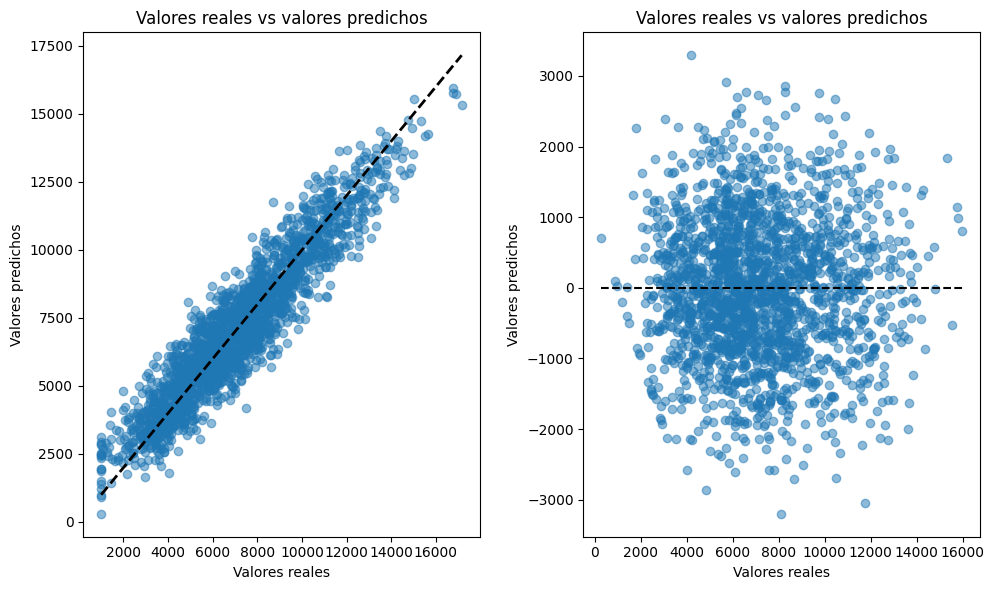

Fitting 5 folds for each of 18 candidates, totalling 90 fits


/usr/local/lib/python3.11/dist-packages/sklearn/linear_model/_coordinate_descent.py:695: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 7.026e+07, tolerance: 4.949e+06
  model = cd_fast.enet_coordinate_descent(
/usr/local/lib/python3.11/dist-packages/sklearn/linear_model/_coordinate_descent.py:695: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 6.916e+07, tolerance: 4.964e+06
  model = cd_fast.enet_coordinate_descent(
/usr/local/lib/python3.11/dist-packages/sklearn/linear_model/_coordinate_descent.py:695: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 6.924e+07, tolerance: 5.007e

R2 Score Lasso: 0.8766292240398161


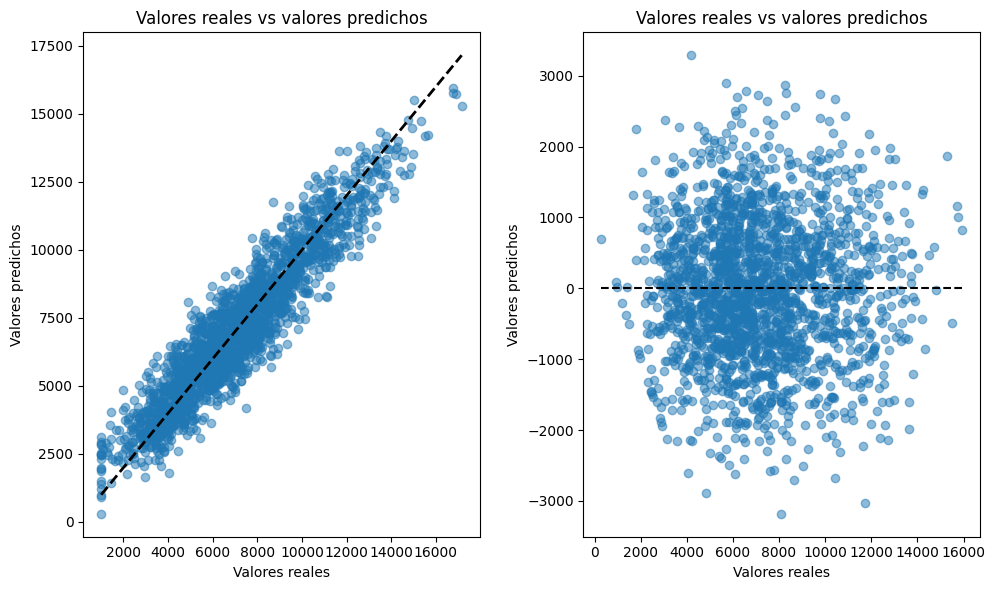

Fitting 5 folds for each of 63 candidates, totalling 315 fits
R2 Score Ridge: 0.8765515643900312


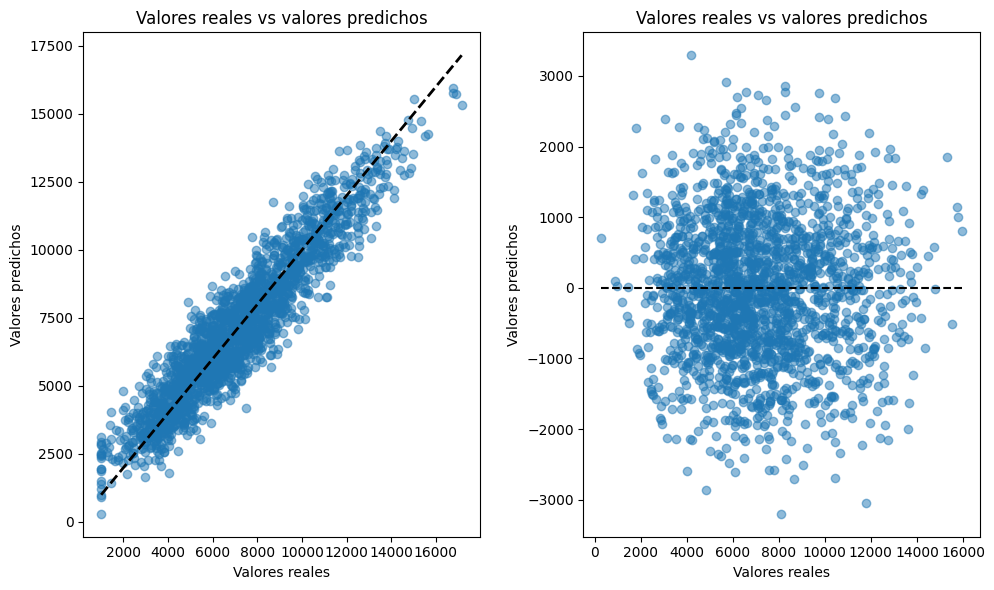

R2 Score Ridge: 0.8765515643900312
R2 Score Lasso: 0.8766292240398161
R2 Score LinReg: 0.8765494410543437


In [ ]:
df = pd.read_csv('/content/drive/MyDrive/Colab Notebooks/used_car_price_dataset_extended.csv')

def plot_results(y_test, y_pred):
  plt.figure(figsize=(10, 6))
  plt.subplot(1,2,1)
  plt.scatter(y_test, y_pred, alpha = 0.5)
  plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'k--', lw = 2)
  plt.xlabel('Valores reales')
  plt.ylabel('Valores predichos')
  plt.title('Valores reales vs valores predichos')

  plt.subplot(1,2,2)
  residuales = y_test - y_pred
  plt.scatter(y_pred, residuales, alpha = 0.5)
  plt.hlines(y = 0, xmin= y_pred.min(), xmax = y_pred.max(), colors = 'k', linestyles = 'dashed')
  plt.xlabel('Valores reales')
  plt.ylabel('Valores predichos')
  plt.title('Valores reales vs valores predichos')
  plt.tight_layout()
  plt.show()
############## Paso 1: Revision de los datos
print(df.head())
print(df.info())
print(df.isnull().sum())

#Grafico de los datos

############## Paso 2: Preprocesamiento de datos (limpia de datos, feature engineering, normalizacion, separacion de datos test/train)

####Datos vacios: Quitarlos / Rellenas los espacios vacios

#Quitar
#df = df.dropna()
#print(df.info())
#print(df.isnull().sum())

#Rellenar valores vacios
print(df["service_history"].unique())

###Caso de los objetos / String

#Reemplazo del valor NaN
df = df.fillna('None') #Rellena todos los valores NaN de la df
df['service_history'] = df["service_history"].fillna(0, inplace = True) #Columna especifica

#print(df["service_history"].unique())

###Caso de valores numericos
# columna = df['engine_cc]

#Reemplazar con la media

#df.fillna(df.mean(), inplace = True) Media de toda la base de datos
#df.fillna(df.mean(), inplace = True) Media de la columna que se quiere rellenar

#Reemplazar con la moda
#.mean() -> .mode()

#####Feature engineering

#Crear nuebavas columnas

#df['nueva_columna = df['accidents_reported] / df['owner_count]
#print(df.head())

###Separacion de los datos

X = df.drop(['price_usd'], axis = 1) #Seleccion de las caracteristicas
y = df['price_usd'] #Seleccion del target


X_train, X_test, y_train, y_test = train_test_split( X, y, test_size = 0.2, random_state = 42)

##Categorias = Text, Numericos

num_cols = X.select_dtypes(exclude = 'object').columns
cat_cols = X.select_dtypes(include='object').columns

#Normalizacion de variable numerica
scaler = StandardScaler()
#Normalizacion de variable categorica
encoder = OneHotEncoder()

preprocessor = ColumnTransformer(
    [
        ('num', scaler, num_cols), ('cat', encoder, cat_cols)
    ]
)

###Normalizar

X_train = preprocessor.fit_transform(X_train)
X_test = preprocessor.transform(X_test)

####################### Paso 3: Entrenamiento del modelo (Declarar el modelo, Buscar los mejores parametros, entrenamiento, score)

#Declarar modelo

lin_reg = LinearRegression()

#Buscar mejors parametros (GridSearchCV)

#Declarar parametros a probar
param_grid = [
    {
        'fit_intercept': [True, False],
        'copy_X': [True, False],
        'positive': [True, False],
        'n_jobs': [1, -1],
    }
]
#Definir el GridSearchCV

grid_search = GridSearchCV(estimator = lin_reg, param_grid = param_grid, cv = 5, scoring = 'neg_mean_squared_error', return_train_score= True, verbose = 1)

#Buscar mejores parametros
grid_search.fit(X_train, y_train)

grid_best_params = grid_search.best_params_
print(f'Best params: {grid_best_params}')

#Entrenamiento del modelo final
lin_reg_final = LinearRegression(**grid_best_params)

#Entrenamos el modelo
lin_reg_final.fit(X_train, y_train)

#Prediccion
y_pred = lin_reg_final.predict(X_test)

##Score

#R2 Score
R2score = r2_score(y_test, y_pred)
print(f'R2 Score: {R2score}')

#Mean Absolute Error(MAE)
MAE = mean_absolute_error(y_test, y_pred)
print(f'MAE: {MAE}')

#Mean Squared Error (MSE)
MSE = mean_squared_error(y_test, y_pred)
print(f'MSE: {MSE}')

#Root Mean Squared Error (RMSE)
RMSE = np.sqrt(MSE)
print(f'RMSE: {RMSE}')

plot_results(y_test, y_pred)

#####L1 Regularization (Lasso)

lasso_model = Lasso()

Lasso_params = [
    {
        'alpha': [0.1, 0.5, 1],
        'max_iter': [100, 500, 1000],
        'selection': ['cyclic', 'random'],
    }
]

grid_search = GridSearchCV(lasso_model, Lasso_params, cv = 5, verbose = 1, scoring = 'neg_mean_squared_error')

grid_search.fit(X_train, y_train)
grid_best_params = grid_search.best_params_
Lassofinal = Lasso(**grid_best_params)
Lassofinal.fit(X_train, y_train)
y_pred = Lassofinal.predict(X_test)

r2scorelasso = r2_score(y_test, y_pred)
print(f'R2 Score Lasso: {r2scorelasso}')

plot_results(y_test, y_pred)


#####L2 Regularization (Ridge)

Ridge_model = Ridge()

Ridge_params = [
    {
        'alpha': [0.1, 0.5, 1],
        'max_iter': [100, 500, 1000],
        'solver': ['auto', 'svd', 'cholesky', 'lsqr', 'sparse_cg', 'sag', 'saga'],
    }
]

grid_search = GridSearchCV(Ridge_model, Ridge_params, cv = 5, verbose = 1, scoring = 'neg_mean_squared_error')

grid_search.fit(X_train, y_train)
grid_best_params = grid_search.best_params_
Ridgefinal = Ridge(**grid_best_params)
Ridgefinal.fit(X_train, y_train)
y_pred = Ridgefinal.predict(X_test)

r2scoreridge = r2_score(y_test, y_pred)
print(f'R2 Score Ridge: {r2scoreridge}')
plot_results(y_test, y_pred)

print(f'R2 Score Ridge: {r2scoreridge}')
print(f'R2 Score Lasso: {r2scorelasso}')
print(f'R2 Score LinReg: {R2score}')